## Logistic Regression / Classification based algorithm
- used sigmoid function / Logit function
- uses logit function (sigmoid function)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# insurance prediction

In [3]:
df=pd.read_csv('insurance_data.csv')
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [4]:
df.shape

(27, 2)

In [5]:
df.dtypes

age                 int64
bought_insurance    int64
dtype: object

In [6]:
df.describe()

,age,bought_insurance
count,27.000000,27.000000
mean,39.666667,0.518519
std,15.745573,0.509175
min,18.000000,0.000000
25%,25.000000,0.000000
50%,45.000000,1.000000
75%,54.500000,1.000000
max,62.000000,1.000000


In [7]:
df.isnull().sum()

age                 0
bought_insurance    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.drop_duplicates(inplace=True, ignore_index=True)

In [10]:
df.shape

(26, 2)

In [11]:
X=df[['age']]
y=df['bought_insurance']

In [12]:
X, y

(    age
 0    22
 1    25
 2    47
 3    52
 4    46
 5    56
 6    55
 7    60
 8    62
 9    61
 10   18
 11   28
 12   27
 13   29
 14   49
 15   55
 16   25
 17   58
 18   19
 19   21
 20   26
 21   40
 22   45
 23   50
 24   54
 25   23,
 0     0
 1     0
 2     1
 3     0
 4     1
 5     1
 6     0
 7     1
 8     1
 9     1
 10    0
 11    0
 12    0
 13    0
 14    1
 15    1
 16    1
 17    1
 18    0
 19    0
 20    0
 21    1
 22    1
 23    1
 24    1
 25    0
 Name: bought_insurance, dtype: int64)

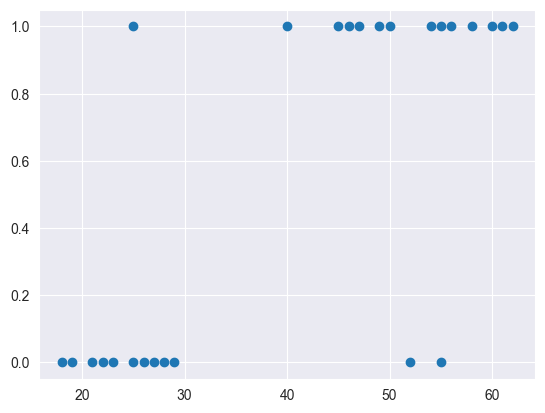

In [13]:
plt.scatter(df['age'], df['bought_insurance'])

In [14]:
# encoding

In [15]:
# scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [16]:
X_sc=sc.fit_transform(X)
X_sc

array([[-1.22205269],
       [-1.02388198],
       [ 0.42936986],
       [ 0.75965437],
       [ 0.36331296],
       [ 1.02388198],
       [ 0.95782508],
       [ 1.28810959],
       [ 1.42022339],
       [ 1.35416649],
       [-1.4862803 ],
       [-0.82571128],
       [-0.89176818],
       [-0.75965437],
       [ 0.56148367],
       [ 0.95782508],
       [-1.02388198],
       [ 1.15599579],
       [-1.42022339],
       [-1.28810959],
       [-0.95782508],
       [-0.03302845],
       [ 0.29725606],
       [ 0.62754057],
       [ 0.89176818],
       [-1.15599579]])

In [17]:
y.value_counts()

bought_insurance
1    14
0    12
Name: count, dtype: int64

In [18]:
# balanced data

In [19]:
# train test fit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X_sc, y, test_size=0.2, random_state=11)

In [20]:
X_train.shape, X_test.shape

((20, 1), (6, 1))

In [21]:
# model training
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()

In [22]:
lg.fit(X_train, y_train)

LogisticRegression()

In [23]:
lg.score(X_test, y_test)

0.6666666666666666

In [24]:
# age=72
new_sc=sc.transform([[12]])
new_sc

C:\Users\LENOVO\PycharmProjects\Machine_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-1.88262171]])

In [25]:
lg.predict(new_sc)

array([0])

In [26]:
y_pred=lg.predict(X_test)
y_pred

array([0, 0, 1, 1, 1, 1])

In [27]:
y_test, y_pred

(10    0
 19    0
 6     0
 14    1
 3     0
 9     1
 Name: bought_insurance, dtype: int64,
 array([0, 0, 1, 1, 1, 1]))

In [28]:
# model performance

In [29]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [30]:
confusion_matrix(y_test, y_pred)

array([[2, 2],
       [0, 2]])

In [31]:
accuracy_score(y_test, y_pred)

0.6666666666666666

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         4
           1       0.50      1.00      0.67         2

    accuracy                           0.67         6
   macro avg       0.75      0.75      0.67         6
weighted avg       0.83      0.67      0.67         6



In [33]:
lg.score(X_train, y_train)

0.95

In [34]:
# Overfitted Model

In [35]:
# example 2
# iris flower classification

In [36]:
df=pd.read_csv('iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [37]:
df.shape

(150, 5)

In [38]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [39]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(1)

In [41]:
df.drop_duplicates(inplace=True, ignore_index=True)

In [42]:
df.shape

(149, 5)

In [43]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

In [44]:
X=df.drop('species', axis=1)
y=df['species']

In [45]:
X, y

(     sepal_length  sepal_width  petal_length  petal_width
 0             5.1          3.5           1.4          0.2
 1             4.9          3.0           1.4          0.2
 2             4.7          3.2           1.3          0.2
 3             4.6          3.1           1.5          0.2
 4             5.0          3.6           1.4          0.2
 ..            ...          ...           ...          ...
 144           6.7          3.0           5.2          2.3
 145           6.3          2.5           5.0          1.9
 146           6.5          3.0           5.2          2.0
 147           6.2          3.4           5.4          2.3
 148           5.9          3.0           5.1          1.8
 
 [149 rows x 4 columns],
 0         setosa
 1         setosa
 2         setosa
 3         setosa
 4         setosa
          ...    
 144    virginica
 145    virginica
 146    virginica
 147    virginica
 148    virginica
 Name: species, Length: 149, dtype: object)

In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
sc=StandardScaler()
X_sc=sc.fit_transform(X)

In [48]:
X_sc

array([[-0.8980334 ,  1.01240113, -1.33325507, -1.30862368],
       [-1.13956224, -0.1373532 , -1.33325507, -1.30862368],
       [-1.38109108,  0.32254853, -1.39001364, -1.30862368],
       [-1.5018555 ,  0.09259766, -1.2764965 , -1.30862368],
       [-1.01879782,  1.242352  , -1.33325507, -1.30862368],
       [-0.53574014,  1.9322046 , -1.16297935, -1.04548613],
       [-1.5018555 ,  0.78245027, -1.33325507, -1.17705491],
       [-1.01879782,  0.78245027, -1.2764965 , -1.30862368],
       [-1.74338434, -0.36730407, -1.33325507, -1.30862368],
       [-1.13956224,  0.09259766, -1.2764965 , -1.44019246],
       [-0.53574014,  1.47230287, -1.2764965 , -1.30862368],
       [-1.26032666,  0.78245027, -1.21973792, -1.30862368],
       [-1.26032666, -0.1373532 , -1.33325507, -1.44019246],
       [-1.86414876, -0.1373532 , -1.50353079, -1.44019246],
       [-0.05268246,  2.16215547, -1.44677222, -1.30862368],
       [-0.17344688,  3.08195894, -1.2764965 , -1.04548613],
       [-0.53574014,  1.

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X_sc, y, test_size=0.2, random_state=11)

In [50]:
X_train.shape, X_test.shape

((119, 4), (30, 4))

In [51]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()

In [52]:
lg.fit(X_train ,y_train)

LogisticRegression()

In [53]:
lg.score(X_test, y_test)*100

93.33333333333333

In [54]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [55]:
new = pd.DataFrame({
    'sepal_length': [6.3],
    'sepal_width': [2.5],
    'petal_length': [5.0],
    'petal_width': [1.9]
})
new

,sepal_length,sepal_width,petal_length,petal_width
0,6.3,2.5,5.0,1.9


In [56]:
new_sc=sc.transform(new)

In [57]:
lg.predict(new_sc)

array(['virginica'], dtype=object)

In [58]:
y_pred=lg.predict(X_test)

In [59]:
cm=confusion_matrix(y_test, y_pred)

<Axes: >

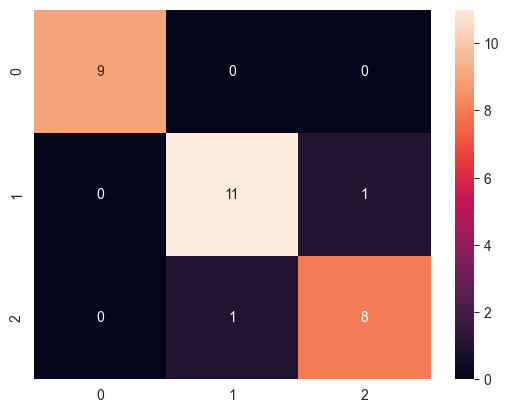

In [60]:
sns.heatmap(cm, annot=True)

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         9
  versicolor       0.92      0.92      0.92        12
   virginica       0.89      0.89      0.89         9

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30



In [62]:
accuracy_score(y_test, y_pred)

0.9333333333333333

In [63]:
# titanic
# o/p = survive only

In [64]:
df=sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [65]:
df.shape

(891, 15)

In [66]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [67]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [68]:
# num_df['GarageYrBlt'].fillna(num_df['GarageYrBlt'].mean(), inplace=True)
df['age'].fillna(df['age'].mean(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17076\2704254332.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17076\2704254332.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [69]:
df.drop(['deck', 'adult_male'], inplace=True, axis=1)

In [70]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
embark_town    0
alive          0
alone          0
dtype: int64

In [71]:
df.duplicated().sum()

np.int64(111)

In [72]:
df.drop_duplicates(inplace=True, ignore_index=True)

In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'embark_town', 'alive', 'alone'],
      dtype='object')

In [75]:
X=df.drop(['survived', 'embark_town', 'class', 'alive'], axis=1)
y=df['survived']

In [76]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [77]:
X

,pclass,sex,age,sibsp,parch,fare,embarked,who,alone
0,3,male,22.000000,1,0,7.2500,S,man,False
1,1,female,38.000000,1,0,71.2833,C,woman,False
2,3,female,26.000000,0,0,7.9250,S,woman,True
3,1,female,35.000000,1,0,53.1000,S,woman,False
4,3,male,35.000000,0,0,8.0500,S,man,True
...,...,...,...,...,...,...,...,...,...
775,3,female,39.000000,0,5,29.1250,Q,woman,False
776,1,female,19.000000,0,0,30.0000,S,woman,True
777,3,female,29.699118,1,2,23.4500,S,woman,False
778,1,male,26.000000,0,0,30.0000,C,man,True


In [78]:
X.columns

Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who',
       'alone'],
      dtype='object')

In [79]:
from sklearn.preprocessing import OneHotEncoder
oh=OneHotEncoder(sparse_output=False)
X[['sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S',
       'who_child', 'who_man', 'who_woman', 'alone_False', 'alone_True']]=oh.fit_transform(X[['sex', 'embarked', 'who', 'alone']])

In [80]:
oh.get_feature_names_out()

array(['sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S',
       'who_child', 'who_man', 'who_woman', 'alone_False', 'alone_True'],
      dtype=object)

In [81]:
X.drop(['sex', 'embarked', 'who', 'alone'], inplace=True, axis=1)

In [82]:
X.columns

Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male',
       'embarked_C', 'embarked_Q', 'embarked_S', 'who_child', 'who_man',
       'who_woman', 'alone_False', 'alone_True'],
      dtype='object')

In [83]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc.fit(X)
X_sc=sc.transform(X)

In [84]:
X_sc

array([[ 0.88282317, -0.56916407,  0.48040606, ..., -0.68680282,
         1.14354375, -1.14354375],
       [-1.45936076,  0.59871127,  0.48040606, ...,  1.45602198,
         1.14354375, -1.14354375],
       [ 0.88282317, -0.27719523, -0.53234185, ...,  1.45602198,
        -0.87447463,  0.87447463],
       ...,
       [ 0.88282317, -0.00718847,  0.48040606, ...,  1.45602198,
         1.14354375, -1.14354375],
       [-1.45936076, -0.27719523, -0.53234185, ..., -0.68680282,
        -0.87447463,  0.87447463],
       [ 0.88282317,  0.16075802, -0.53234185, ..., -0.68680282,
        -0.87447463,  0.87447463]])

In [85]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X_sc, y, test_size=0.2, random_state=11)

In [86]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()
lg.fit(X_train, y_train)

LogisticRegression()

In [87]:
lg.score(X_test, y_test)

0.8269230769230769

In [88]:
y_pred=lg.predict(X_test)

In [89]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [90]:
confusion_matrix(y_test, y_pred)

array([[74, 10],
       [17, 55]])

In [91]:
accuracy_score(y_test, y_pred)

0.8269230769230769

In [92]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.85        84
           1       0.85      0.76      0.80        72

    accuracy                           0.83       156
   macro avg       0.83      0.82      0.82       156
weighted avg       0.83      0.83      0.83       156



<Axes: >

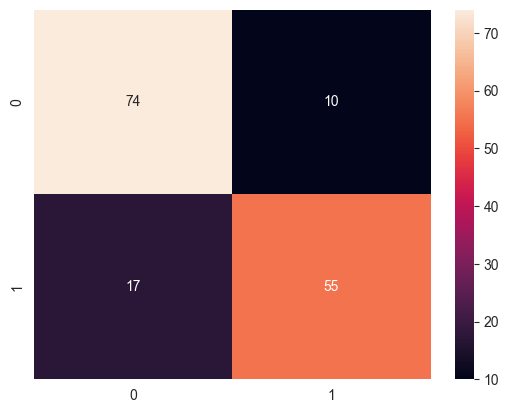

In [93]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

In [94]:
# 3,female,19.0,0,0,7.8792,Q,Third,woman,False,NaN,Queenstown,yes,True

new= pd.DataFrame({
    'pclass':[3],
    'age':[19],
    'sibsp':[0],
    'parch':[0],
    'fare':[7.8792],
    'sex_female':[1.0],
    'sex_male':[0.0],
    'embarked_C':[0.0],
    'embarked_Q':[1.0],
    'embarked_S':[0.0],
    'who_child':[0.0], 'who_man':[0.0],
    'who_woman':[1.0],
    'alone_False':[0.0], 'alone_True':[1.0]
})
new

,pclass,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,who_child,who_man,who_woman,alone_False,alone_True
0,3,19,0,0,7.8792,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [95]:
new_sc=sc.transform(new)

In [96]:
lg.predict(new_sc)

array([1])

In [97]:
# digit classification

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [99]:
from sklearn.datasets import load_digits
data=load_digits()

In [100]:
X=data.data

In [101]:
y=data.target

In [102]:
X, y

(array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 array([0, 1, 2, ..., 8, 9, 8]))

In [103]:
X.shape, y.shape

((1797, 64), (1797,))

In [104]:
df=pd.DataFrame(X, columns=data.feature_names)

In [105]:
df['target']=y

In [106]:
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [107]:
df['target'].value_counts()

target
3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64

In [108]:
data.images.shape

(1797, 8, 8)

In [109]:
data.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

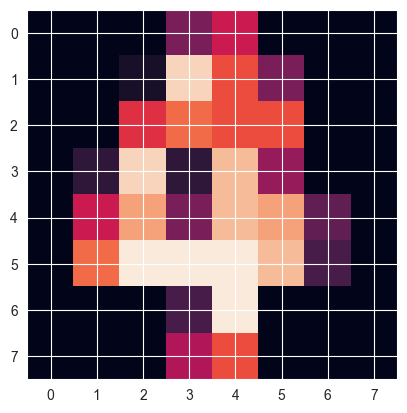

In [110]:
plt.imshow(data.images[450])

In [111]:
X_sc=X/255

In [112]:
X_sc

array([[0.        , 0.        , 0.01960784, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.03921569, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.0627451 , 0.03529412,
        0.        ],
       ...,
       [0.        , 0.        , 0.00392157, ..., 0.02352941, 0.        ,
        0.        ],
       [0.        , 0.        , 0.00784314, ..., 0.04705882, 0.        ,
        0.        ],
       [0.        , 0.        , 0.03921569, ..., 0.04705882, 0.00392157,
        0.        ]])

In [113]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X_sc, y, test_size=0.2, random_state=11)

In [114]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()

In [115]:
lr.fit(X_train, y_train)

LogisticRegression()

In [116]:
lr.score(X_test, y_test)

0.8888888888888888

In [117]:
from PIL import Image

In [118]:
image = Image.open('unnamed.png')

In [119]:
image = np.array(image)
image

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [120]:
image.shape

(304, 309, 3)

In [121]:
image.data

In [122]:
image.target

AttributeError: 'numpy.ndarray' object has no attribute 'target'